In [16]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from matplotlib.colors import ListedColormap

# 1. 데이터 로드
iris = load_iris() # 사이킷런에서 붓꽃데이터를 제공

In [6]:
# 독립, 종속 분리
X = iris.data[:, 2:4] # 2번째, 3번째 컬럼(petal length, petal width)
y = iris.target

In [7]:
# 훈련, 테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

In [8]:
# 스케일링 : 거리계산을 위해서 => 독립변수들의 범위가 같도록
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# 학습
k = 3 # 그룹을 3개로 구분
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [12]:
accuracy = knn.score(X_test_scaled, y_test)
print(f"테스트 데이터 정확도: {accuracy:.2f}")

테스트 데이터 정확도: 0.93


In [14]:
# 시각화 범위 설정 (스케일링 된 데이터 기준)
# -0.5, +0.5는 그래프 여백
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
hh = 0.02 # 바닥에 까는 크물망의 크기(점으로 색을 칠함)
xx, yy = np.meshgrid(np.arange(x_min, x_max, hh),
                     np.arange(y_min, y_max, hh))

# 그리드 데이터 예측 (스케일링 된 상태로 입력)
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

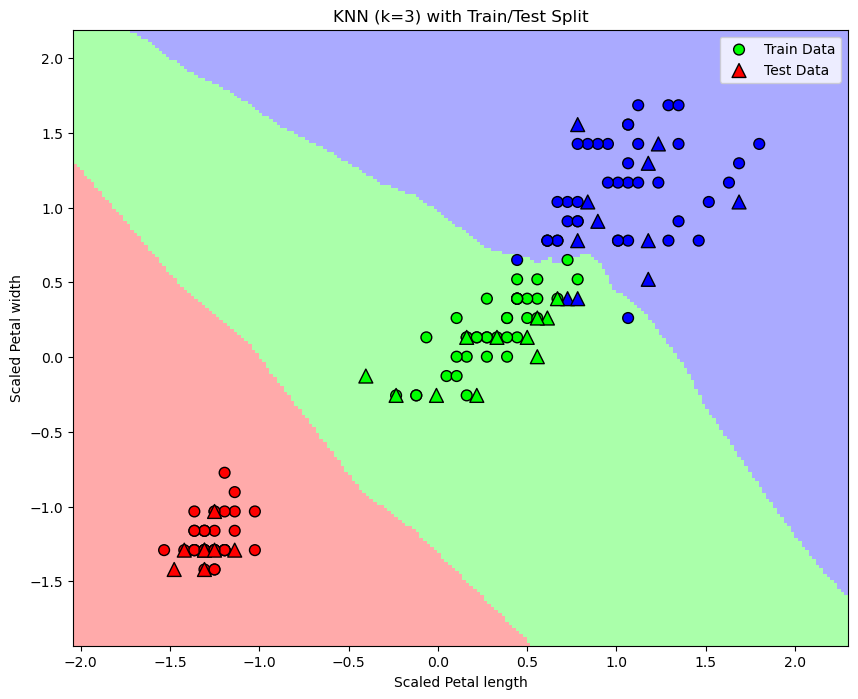

In [17]:
# 시각화
# 배경색을 칠한 색상 지정
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
# 데이터를 찍을 색상 지정
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.figure(figsize=(10, 8))
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# 훈련 데이터 표시
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, 
            cmap=cmap_bold, edgecolor='k', s=60, label='Train Data')

# 테스트 데이터 표시 (삼각형 모양)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, 
            cmap=cmap_bold, marker='^', edgecolor='k', s=100, label='Test Data')

plt.xlabel('Scaled Petal length')
plt.ylabel('Scaled Petal width')
plt.title(f'KNN (k={k}) with Train/Test Split')
plt.legend()
plt.show()